Import Libraries

In [ ]:
import ultralytics
import supervision
import torch
import cv2
from collections import defaultdict
import supervision as sv
from ultralytics import YOLO
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import ffmpeg
import subprocess

Define Model

In [25]:
model1 = YOLO("yolov8n.pt")
results1 = model1("output_high.mp4", stream=True)
results1 = list(results1)

model2 = YOLO("yolov8n.pt")
results2 = model2("output_medium.mp4", stream=True)
results2 = list(results2)

model3 = YOLO("yolov8n.pt")
results3 = model3("output_low.mp4", stream=True)
results3 = list(results3)

video 1/1 (frame 264/687) /Users/calebfree/Documents/Development/Comp590/CV_Project/output_high.mp4: 384x640 6 cars, 2 stop signs, 50.7ms
video 1/1 (frame 265/687) /Users/calebfree/Documents/Development/Comp590/CV_Project/output_high.mp4: 384x640 6 cars, 1 truck, 2 stop signs, 55.8ms
video 1/1 (frame 266/687) /Users/calebfree/Documents/Development/Comp590/CV_Project/output_high.mp4: 384x640 7 cars, 2 stop signs, 20.0ms
video 1/1 (frame 267/687) /Users/calebfree/Documents/Development/Comp590/CV_Project/output_high.mp4: 384x640 6 cars, 2 stop signs, 20.3ms
video 1/1 (frame 268/687) /Users/calebfree/Documents/Development/Comp590/CV_Project/output_high.mp4: 384x640 7 cars, 2 stop signs, 19.7ms
video 1/1 (frame 269/687) /Users/calebfree/Documents/Development/Comp590/CV_Project/output_high.mp4: 384x640 8 cars, 2 stop signs, 18.0ms
video 1/1 (frame 270/687) /Users/calebfree/Documents/Development/Comp590/CV_Project/output_high.mp4: 384x640 7 cars, 2 stop signs, 18.9ms
video 1/1 (frame 271/687)

Handle Results

frames compared high to medium: 687
total difference high to medium: 595
mean per-frame difference high to medium: 0.86608442503639
frames compared high to low 687
total difference high to low: 842
mean per-frame difference high to low: 1.225618631732169


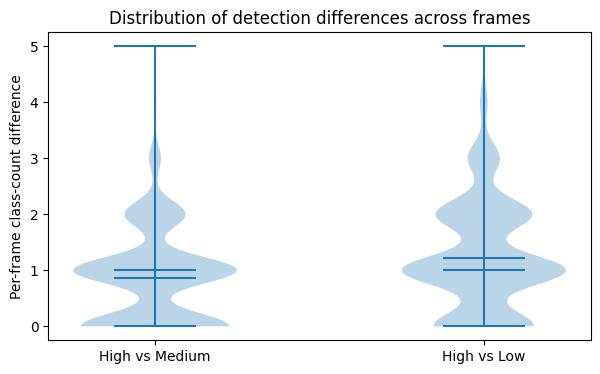

In [26]:


frame_diffs_high_medium = []
frame_diffs_high_low = []

for r1, r2 in zip(results1, results2):
    c1 = Counter(int(box.cls[0]) for box in r1.boxes)
    c2 = Counter(int(box.cls[0]) for box in r2.boxes)

    all_cls = set(c1) | set(c2)
    diff = sum(abs(c1.get(k, 0) - c2.get(k, 0)) for k in all_cls)
    frame_diffs_high_medium.append(diff)

print("frames compared high to medium:", len(frame_diffs_high_medium))
print("total difference high to medium:", sum(frame_diffs_high_medium))
print("mean per-frame difference high to medium:", sum(frame_diffs_high_medium) / max(len(frame_diffs_high_medium), 1))

for r1, r3 in zip(results1, results3):
    c1 = Counter(int(box.cls[0]) for box in r1.boxes)
    c3 = Counter(int(box.cls[0]) for box in r3.boxes)

    all_cls = set(c1) | set(c3)
    diff = sum(abs(c1.get(k, 0) - c3.get(k, 0)) for k in all_cls)
    frame_diffs_high_low.append(diff)

print("frames compared high to low", len(frame_diffs_high_low))
print("total difference high to low:", sum(frame_diffs_high_low))
print("mean per-frame difference high to low:", sum(frame_diffs_high_low) / max(len(frame_diffs_high_low), 1))

fig, ax = plt.subplots(figsize=(7, 4))
ax.violinplot([frame_diffs_high_medium, frame_diffs_high_low], positions=[1, 2], showmeans=True, showmedians=True)
ax.set_xticks([1, 2])
ax.set_xticklabels(["High vs Medium", "High vs Low"])
ax.set_ylabel("Per-frame class-count difference")
ax.set_title("Distribution of detection differences across frames")
plt.show()